In [168]:
import cv2
import mediapipe as mp
import pandas as pd
import os

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def run_extraction():
    input_path = 'data' 
    output_file = 'yoga_poses_raw.csv'
    all_data = []
    
    headers = []
    for i in range(33):
        headers.extend([f'x{i}', f'y{i}', f'z{i}', f'v{i}'])
    headers.append('pose_label')

    if not os.path.exists(input_path):
        print(f"Error: '{input_path}' folder not found.")
        return

    for label in os.listdir(input_path):
        label_path = os.path.join(input_path, label)
        
        if not os.path.isdir(label_path) or label.startswith('.'):
            continue
            
        print(f"Processing category: {label}")
        
        for img_name in os.listdir(label_path):
            if img_name.startswith('.'): continue
            
            img_path = os.path.join(label_path, img_name)
            image = cv2.imread(img_path)
            if image is None: continue
            
            # Process image and extract landmarks
            results = pose.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            
            if results.pose_landmarks:
                landmarks = []
                for lm in results.pose_landmarks.landmark:
                    landmarks.extend([lm.x, lm.y, lm.z, lm.visibility])
                
                landmarks.append(label)
                all_data.append(landmarks)

    # Save features to CSV for the EDA and Modeling teams
    df = pd.DataFrame(all_data, columns=headers)
    df.to_csv(output_file, index=False)
    print(f"\nSUCCESS: Generated {output_file} with {len(df)} samples.")

run_extraction()

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Error: 'data' folder not found.


In [8]:
import pandas as pd

# Load the newly created CSV
df = pd.read_csv('yoga_poses_raw.csv')

# Display the count of successful extractions per pose
print("--- Extraction Summary ---")
print(f"Total Samples: {len(df)}")
print("\nSamples per Pose:")
print(df['pose_label'].value_counts())


for i in range(4, len(df.columns), 4):
    if(i == len(df.columns)-1):
        break

    df.iloc[:, i] = df.iloc[:, i]- df.iloc[:, 0]

df.iloc[:, 0] = df.iloc[:, 0]- df.iloc[:, 0]

# for i in range(5, len(df.columns), 4):
#     if(i == len(df.columns)-1):
#         break
#     df.iloc[:, i] = df.iloc[:, i]- df.iloc[:, 1]

# df.iloc[:, 1] = df.iloc[:, 1]- df.iloc[:, 1]



# Quick check of the coordinate structure
print("\nFirst 5 rows of extracted landmarks:")
display(df.head())
print(df.shape)


df.to_csv("normalized.csv", index=False)

--- Extraction Summary ---
Total Samples: 2582

Samples per Pose:
pose_label
Ardha Matsyendrasana             93
Bitilasana                       90
Ustrasana                        82
Garudasana                       81
Vasisthasana                     79
Bakasana                         79
Baddha Konasana                  75
Adho Mukha Svanasana             72
Anjaneyasana                     71
Utkatasana                       70
Balasana                         69
Padmasana                        68
Virabhadrasana Three             68
Malasana                         68
Utthita Parsvakonasana           68
Vrksasana                        67
Phalakasana                      66
Uttanasana                       66
Urdhva Mukha Svsnssana           66
Setu Bandha Sarvangasana         65
Salamba Sarvangasana             65
Utthita Hasta Padangusthasana    63
Virabhadrasana One               63
Camatkarasana                    62
Halasana                         61
Adho Mukha Vrksasana   

,x0,y0,z0,v0,x1,y1,z1,v1,x2,y2,...,v30,x31,y31,z31,v31,x32,y32,z32,v32,pose_label
0,0.0,0.362337,-0.192382,0.998940,-0.021299,0.339450,-0.164938,0.998815,-0.023404,0.340103,...,0.878728,0.524539,0.194549,0.127038,0.330704,0.542224,0.165187,-0.189368,0.872404,Navasana
1,0.0,0.329545,-0.058629,0.999542,0.018023,0.315116,-0.095684,0.999347,0.021208,0.317069,...,0.306932,-0.486743,0.065220,-0.053977,0.941585,-0.483778,0.075145,0.206979,0.383856,Navasana
2,0.0,0.258715,0.009978,0.999695,-0.016334,0.234360,0.030555,0.999684,-0.017814,0.234757,...,0.923736,0.371212,0.189349,0.108396,0.291949,0.378521,0.178488,-0.151275,0.933541,Navasana
3,0.0,0.153104,-0.117234,0.998965,-0.029684,0.140156,-0.082233,0.998850,-0.032507,0.141585,...,0.747811,0.645551,0.216375,0.388001,0.293067,0.645112,0.204379,0.092685,0.769687,Navasana
4,0.0,0.153104,-0.117234,0.998965,-0.029684,0.140156,-0.082233,0.998850,-0.032507,0.141585,...,0.747811,0.645551,0.216375,0.388001,0.293067,0.645112,0.204379,0.092685,0.769687,Navasana


(2582, 133)


In [9]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install pandas scikit-learn matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
!pip install pandas scikit-learn matplotlib ipykernel


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your raw features
df = pd.read_csv('normalized.csv')

# Perform the Split
# We use 'stratify' so that if 10% of your data is 'Tree Pose', 
# 10% of your Training set AND 10% of your Test set will be 'Tree Pose'.
train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['pose_label']
)

# 3. Save the separate files
train_df.to_csv('yoga_poses_train.csv', index=False)
test_df.to_csv('yoga_poses_test.csv', index=False)

print("Success! Data pipeline complete.")
print(f"Total samples: {len(df)}")
print(f"Training: {len(train_df)} | Testing: {len(test_df)}")

Success! Data pipeline complete.
Total samples: 2582
Training: 2065 | Testing: 517


In [13]:
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/var/folders/9j/9nqvc8b95lv6zqz42_d388nw0000gn/T/ipykernel_53679/657745115.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, y='pose_label', order=train_df['pose_label'].value_counts().index, palette='viridis')


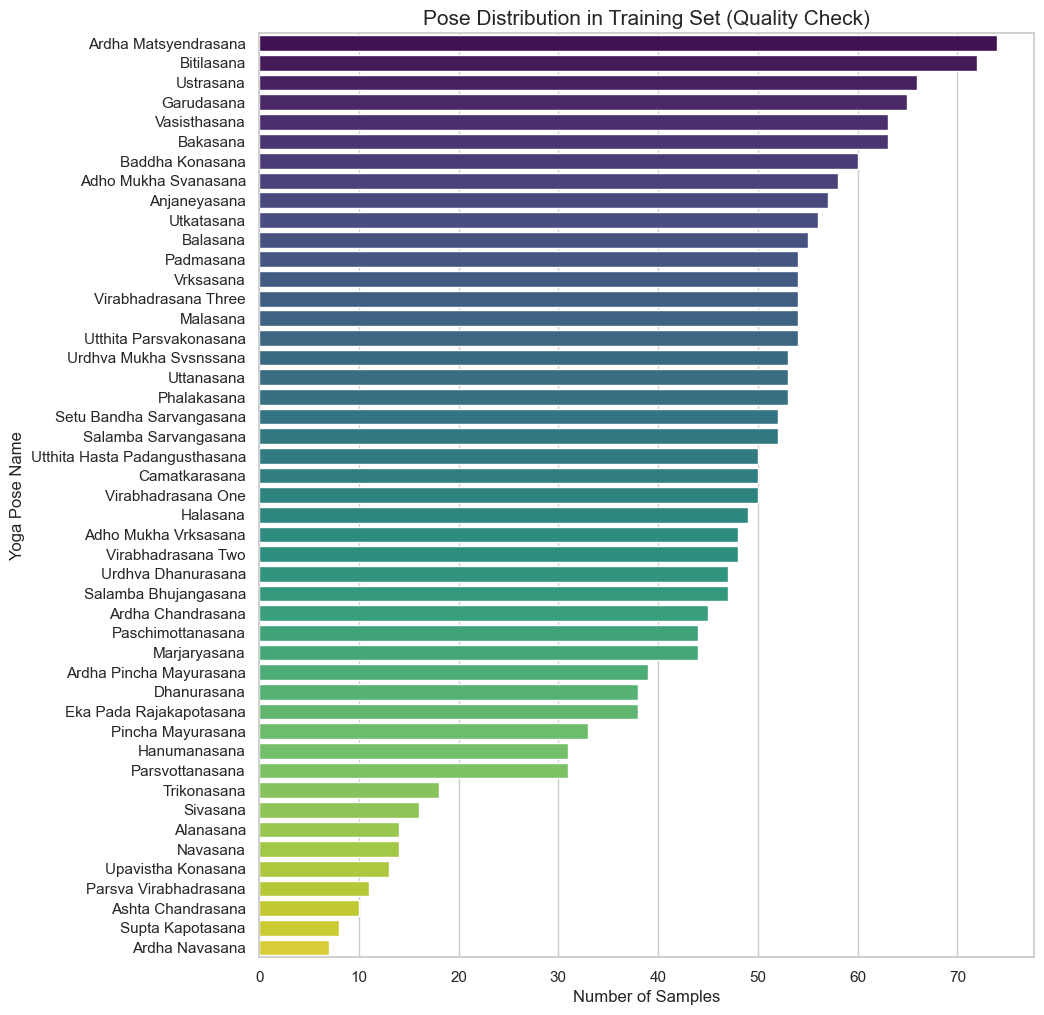

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reloading the training data that was just just made
train_df = pd.read_csv('yoga_poses_train.csv')

# Setting the visual style
sns.set_theme(style="whitegrid")

# Creating the plot
plt.figure(figsize=(10, 12)) # Tall enough to see all pose names
sns.countplot(data=train_df, y='pose_label', order=train_df['pose_label'].value_counts().index, palette='viridis')

plt.title('Pose Distribution in Training Set (Quality Check)', fontsize=15)
plt.xlabel('Number of Samples')
plt.ylabel('Yoga Pose Name')
plt.show()